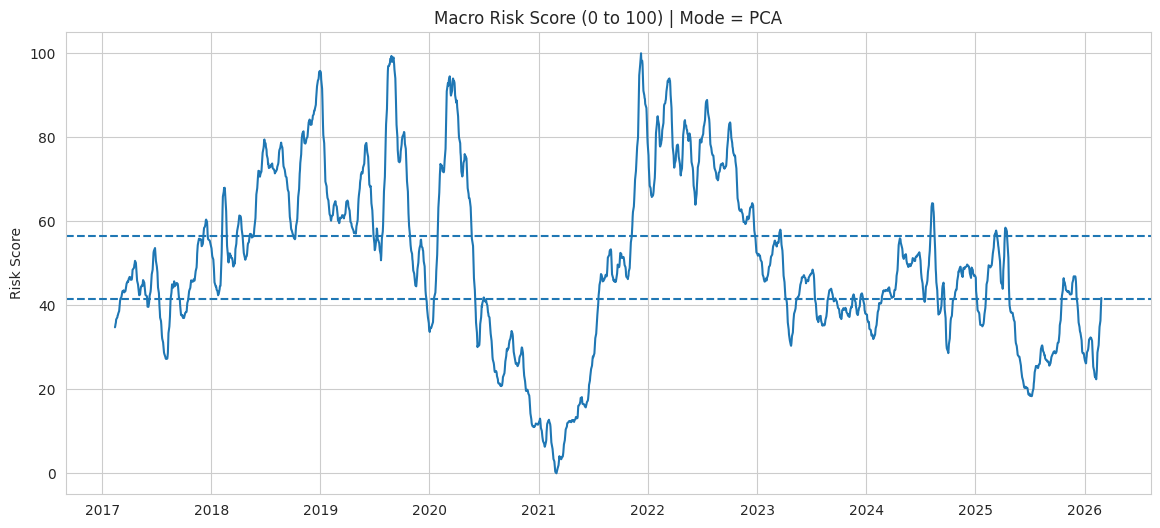

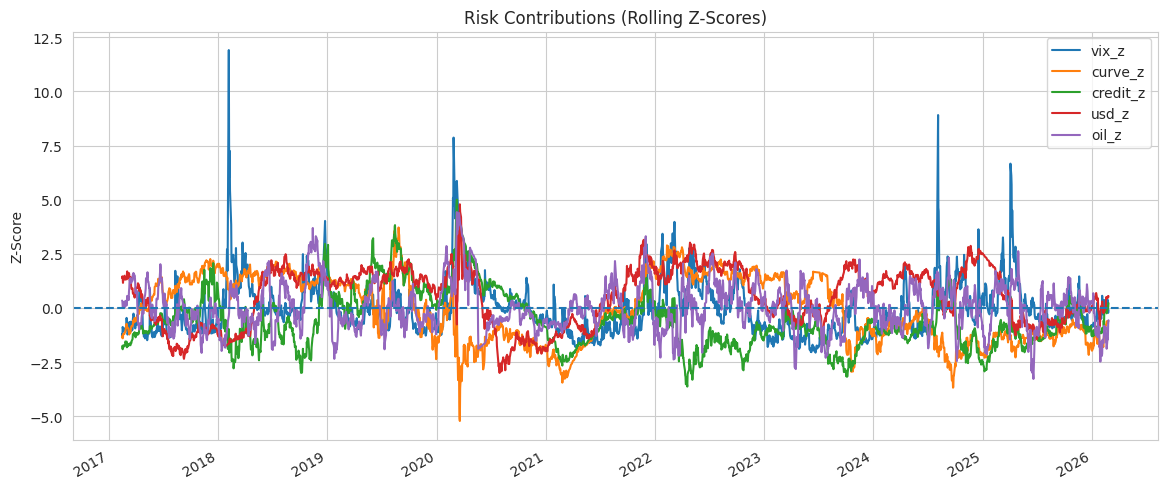

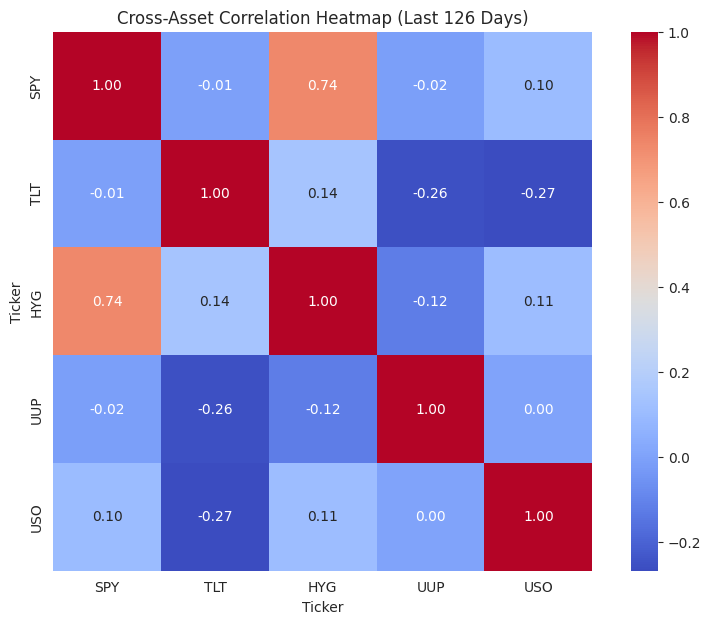

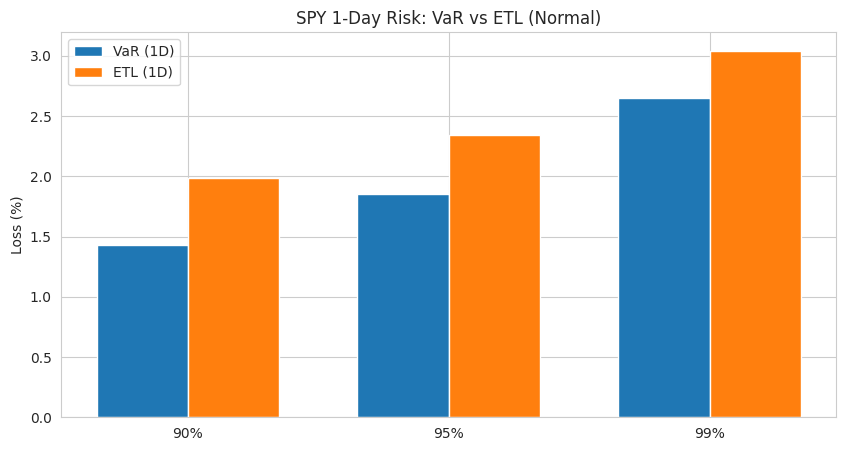

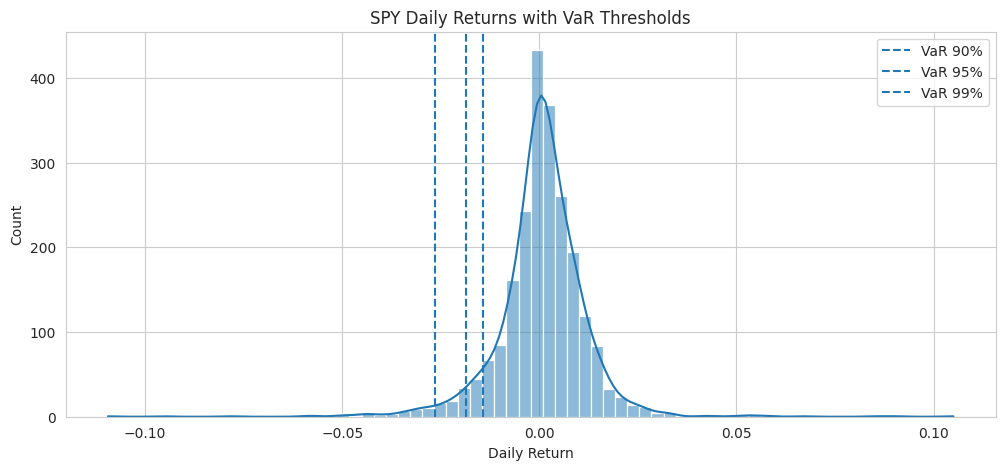

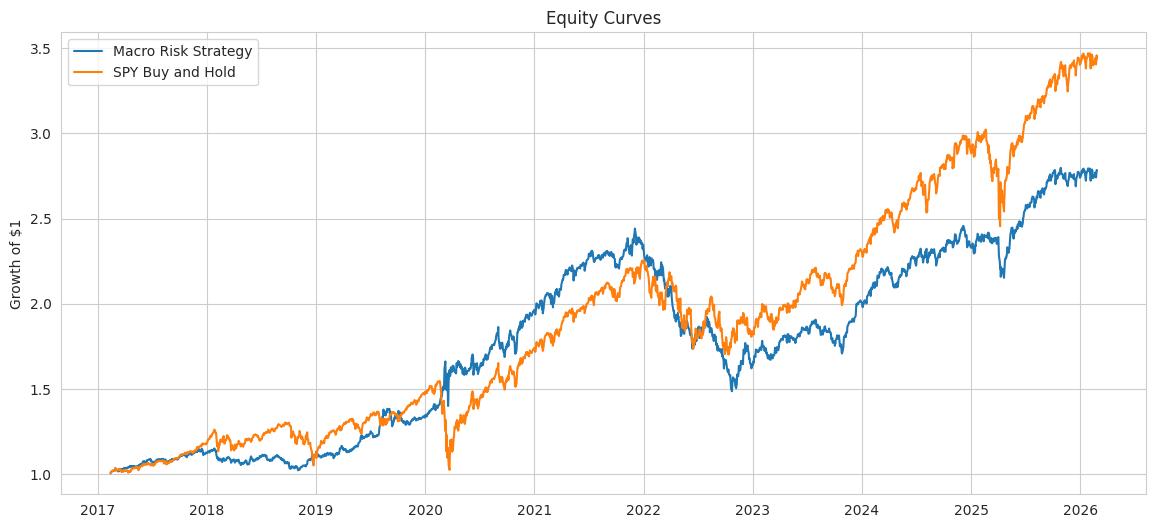

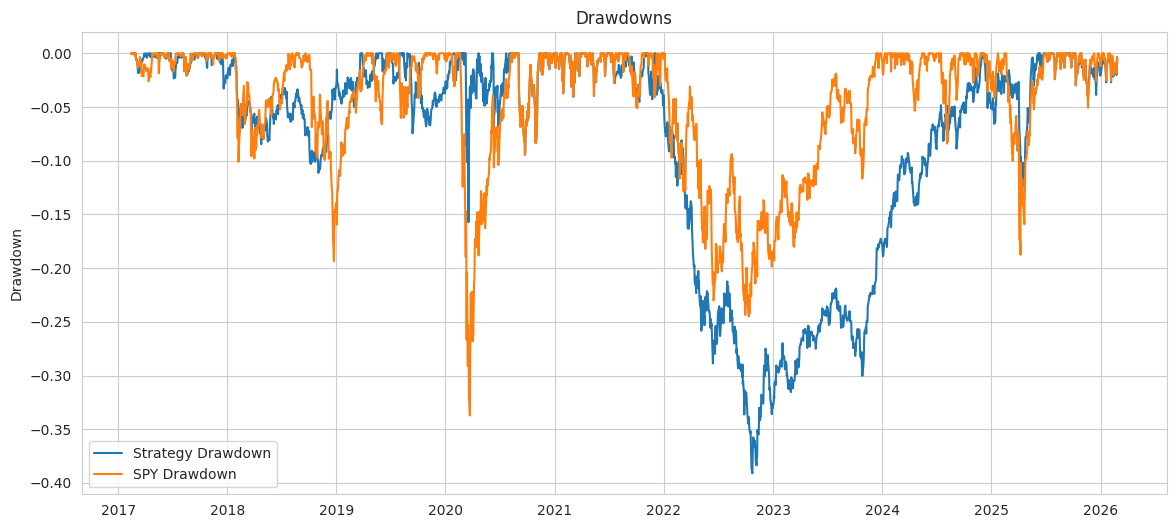

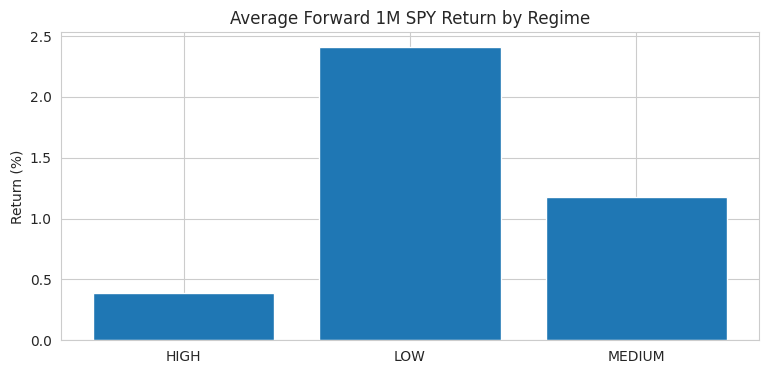

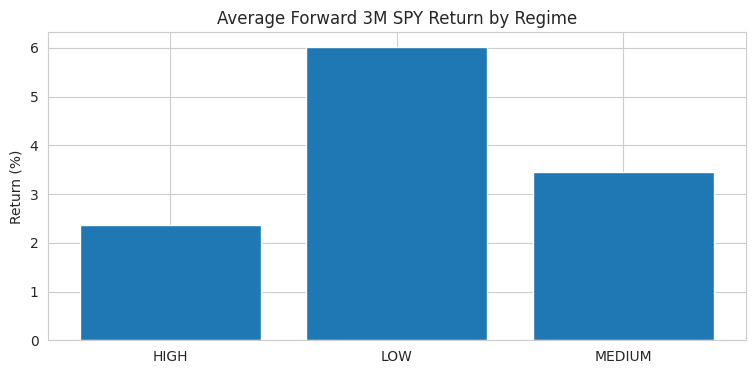

PERFORMANCE SUMMARY
Score mode               : pca
Strategy Sharpe          : 0.876
SPY Sharpe               : 0.834
Strategy Total Return    : 178.28%
SPY Total Return         : 243.92%
Strategy Max Drawdown    : -39.10%
SPY Max Drawdown         : -33.72%

Risk numbers (SPY, Normal):
VaR 90%: 1.43% | ETL 90%: 1.98%
VaR 95%: 1.85% | ETL 95%: 2.34%
VaR 99%: 2.65% | ETL 99%: 3.04%

Forward SPY returns by regime:
1M: {'HIGH': 0.39, 'LOW': 2.41, 'MEDIUM': 1.17}
3M: {'HIGH': 2.36, 'LOW': 6.02, 'MEDIUM': 3.45}

Most recent dashboard rows:


,vix_z,curve_z,credit_z,usd_z,oil_z,macro_z_equal,macro_z_equal_smooth,macro_z_pca,macro_z_pca_smooth,macro_score,regime
2026-02-12,0.372149,-0.805935,-0.227981,-0.148308,-0.813333,-0.324681,-0.838445,-0.818197,-1.801548,26.800207,LOW
2026-02-13,0.325413,-0.966139,-0.039474,-0.138661,-1.104369,-0.384646,-0.757978,-0.961546,-1.650939,28.755537,LOW
2026-02-17,0.260687,-0.795969,0.048786,0.054863,-0.874343,-0.261195,-0.688175,-0.687806,-1.515718,30.511096,LOW
2026-02-18,0.125225,-0.792579,-0.147067,0.416515,-1.594408,-0.398463,-0.635163,-0.799359,-1.400026,32.013105,LOW
2026-02-19,0.241824,-0.701922,-0.119915,0.515268,-1.611128,-0.335174,-0.570612,-0.639064,-1.264887,33.767581,LOW
2026-02-20,0.014017,-0.610300,-0.240086,0.469192,-1.874133,-0.448262,-0.536532,-0.810251,-1.181158,34.854622,LOW
2026-02-23,0.389127,-0.605634,-0.027608,0.482406,-1.381332,-0.228608,-0.486196,-0.447738,-1.067843,36.325777,LOW
2026-02-24,0.099657,-0.690013,0.076950,0.541293,-1.444979,-0.283418,-0.414280,-0.575099,-0.905545,38.432861,LOW
2026-02-25,-0.219540,-0.594833,0.031717,0.492062,-0.757748,-0.209668,-0.356386,-0.491524,-0.774340,40.136264,LOW
2026-02-26,-0.080637,-0.590172,0.233465,0.551400,-0.561950,-0.089579,-0.296370,-0.288226,-0.651881,41.726133,MEDIUM


In [ ]:
# ============================================================
# MACRO RISK DASHBOARD
# Yahoo Finance + FRED, Composite Score + PCA, Regimes, VaR/ETL,
# Correlation heatmap, forward returns, and strategy backtest
# ============================================================

!pip -q install yfinance pandas numpy matplotlib seaborn pandas_datareader scikit-learn scipy

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as pdr
from sklearn.decomposition import PCA
from scipy.stats import norm

plt.rcParams["figure.figsize"] = (14, 6)
sns.set_style("whitegrid")

START = "2016-01-01"

# ------------------------------------------------------------
# 1) Robust Yahoo loader (fixes 'Adj Close' KeyError)
# ------------------------------------------------------------
def fetch_yahoo_prices(tickers, start=START, end=None):
    raw = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=False)

    # yfinance can return MultiIndex columns with levels like ("Adj Close", "SPY")
    if isinstance(raw.columns, pd.MultiIndex):
        lvl0 = raw.columns.get_level_values(0)
        if "Adj Close" in lvl0:
            px = raw["Adj Close"].copy()
        else:
            px = raw["Close"].copy()
    else:
        # Sometimes returns a simple DataFrame already
        px = raw.copy()

    px = px.sort_index().ffill().dropna(how="all")
    return px

def fetch_fred(series, start=START, end=None):
    end = end if end is not None else pd.Timestamp.today().strftime("%Y-%m-%d")
    df = pdr.DataReader(series, "fred", start, end)
    return df.sort_index().ffill().dropna(how="all")

def rolling_zscore(x, window=252):
    mu = x.rolling(window).mean()
    sd = x.rolling(window).std(ddof=1)
    return (x - mu) / sd

def winsorize(s, lo_q=0.01, hi_q=0.99):
    lo = s.quantile(lo_q)
    hi = s.quantile(hi_q)
    return s.clip(lo, hi)

def minmax_0_100(s):
    s = s.copy()
    return 100.0 * (s - s.min()) / (s.max() - s.min())

def compute_drawdown(eq):
    peak = eq.cummax()
    return eq / peak - 1.0

def sharpe(daily_ret, trading_days=252):
    mu = daily_ret.mean()
    sd = daily_ret.std(ddof=1)
    return np.nan if sd == 0 else (mu / sd) * np.sqrt(trading_days)

# ------------------------------------------------------------
# 2) Load data (Yahoo + FRED)
# ------------------------------------------------------------
Y_TICKERS = ["SPY", "TLT", "HYG", "UUP", "USO", "^VIX"]
px = fetch_yahoo_prices(Y_TICKERS, start=START)

fred = fetch_fred(["DGS2", "DGS10"], start=START)  # yields in percent
fred_dec = fred / 100.0
curve_slope = fred_dec["DGS10"] - fred_dec["DGS2"]  # 10y - 2y

# Align dates
common = px.index.intersection(curve_slope.index)
px = px.loc[common].copy()
curve_slope = curve_slope.loc[common].copy()

# Returns (only for tradable assets)
rets_assets = px[["SPY", "TLT", "HYG", "UUP", "USO"]].pct_change().dropna()

# ------------------------------------------------------------
# 3) Build signals (levels and transformed measures)
# ------------------------------------------------------------
signals = pd.DataFrame(index=px.index)

# VIX level (higher = more risk)
signals["VIX_level"] = px["^VIX"]

# Curve slope (lower or negative = more risk, so we will invert later)
signals["Curve_slope_10y2y"] = curve_slope

# Credit stress: HYG vs TLT (falling ratio = more risk)
signals["Credit_log_ratio"] = np.log(px["HYG"] / px["TLT"])

# USD strength (higher = more risk-off proxy, simple)
signals["USD_log_level"] = np.log(px["UUP"])

# Oil shock: use 20d return, negative big moves = stress proxy
signals["Oil_20d_return"] = px["USO"].pct_change(20)

signals = signals.ffill().dropna()

# Winsorize to reduce extreme spikes
for c in signals.columns:
    signals[c] = winsorize(signals[c], 0.01, 0.99)

# ------------------------------------------------------------
# 4) Convert to risk contributions (rolling z-scores)
# Higher should mean "more risk"
# ------------------------------------------------------------
WINDOW = 252

risk = pd.DataFrame(index=signals.index)

risk["vix_z"]   = rolling_zscore(signals["VIX_level"], window=WINDOW)

# Curve: lower slope = more risk => invert
risk["curve_z"] = -rolling_zscore(signals["Curve_slope_10y2y"], window=WINDOW)

# Credit: falling HYG/TLT ratio = more risk => invert log ratio
risk["credit_z"] = -rolling_zscore(signals["Credit_log_ratio"], window=WINDOW)

# USD: higher = more risk proxy
risk["usd_z"] = rolling_zscore(signals["USD_log_level"], window=WINDOW)

# Oil: negative 20d return = more risk => invert
risk["oil_z"] = rolling_zscore(-signals["Oil_20d_return"], window=WINDOW)

risk = risk.dropna()

# ------------------------------------------------------------
# 5) Composite Score (two versions)
# (A) Equal-weight average of z-scores
# (B) PCA factor based score
# ------------------------------------------------------------
risk["macro_z_equal"] = risk[["vix_z", "curve_z", "credit_z", "usd_z", "oil_z"]].mean(axis=1)

# Smooth both
risk["macro_z_equal_smooth"] = risk["macro_z_equal"].rolling(10).mean()

# PCA factor (1 component)
pca = PCA(n_components=1)
Z = risk[["vix_z", "curve_z", "credit_z", "usd_z", "oil_z"]].dropna()
pca_factor = pca.fit_transform(Z)
risk.loc[Z.index, "macro_z_pca"] = pca_factor.flatten()
risk["macro_z_pca_smooth"] = risk["macro_z_pca"].rolling(10).mean()

# Choose which score to drive regimes/backtest
# Pick "pca" or "equal"
SCORE_MODE = "pca"  # change to "equal" if you prefer

if SCORE_MODE == "pca":
    base = risk["macro_z_pca_smooth"].dropna()
else:
    base = risk["macro_z_equal_smooth"].dropna()

risk = risk.loc[base.index].copy()
risk["macro_score"] = minmax_0_100(base)

# ------------------------------------------------------------
# 6) Regime classification
# ------------------------------------------------------------
low_thr = risk["macro_score"].quantile(0.33)
high_thr = risk["macro_score"].quantile(0.66)

def label_regime(x):
    if x <= low_thr:
        return "LOW"
    if x >= high_thr:
        return "HIGH"
    return "MEDIUM"

risk["regime"] = risk["macro_score"].apply(label_regime)

# ------------------------------------------------------------
# 7) Forward returns by regime (SPY)
# ------------------------------------------------------------
spy_ret = px["SPY"].pct_change().loc[risk.index].dropna()

forward_1m = spy_ret.rolling(21).sum().shift(-21)
forward_3m = spy_ret.rolling(63).sum().shift(-63)

fwd = pd.DataFrame({
    "Regime": risk["regime"],
    "Fwd_1M": forward_1m,
    "Fwd_3M": forward_3m
}).dropna()

regime_perf_1m = fwd.groupby("Regime")["Fwd_1M"].mean()
regime_perf_3m = fwd.groupby("Regime")["Fwd_3M"].mean()

# ------------------------------------------------------------
# 8) VaR and Expected Tail Loss (Normal, on SPY daily returns)
# ------------------------------------------------------------
def parametric_var(returns, alpha=0.95):
    mu = returns.mean()
    sigma = returns.std(ddof=1)
    return -(mu + sigma * norm.ppf(1 - alpha))

def expected_tail_loss(returns, alpha=0.95):
    mu = returns.mean()
    sigma = returns.std(ddof=1)
    z = norm.ppf(alpha)
    return -(mu - sigma * norm.pdf(z) / (1 - alpha))

var_90 = parametric_var(spy_ret, 0.90)
var_95 = parametric_var(spy_ret, 0.95)
var_99 = parametric_var(spy_ret, 0.99)

etl_90 = expected_tail_loss(spy_ret, 0.90)
etl_95 = expected_tail_loss(spy_ret, 0.95)
etl_99 = expected_tail_loss(spy_ret, 0.99)

# ------------------------------------------------------------
# 9) Strategy backtest (risk-on/off allocation)
# LOW: 100% SPY
# MEDIUM: 50/50 SPY/TLT
# HIGH: 100% TLT
# ------------------------------------------------------------
ret_bt = px[["SPY", "TLT"]].pct_change().loc[risk.index].dropna()

weights = pd.DataFrame(index=ret_bt.index, columns=["w_spy", "w_tlt"], dtype=float)

weights.loc[risk["regime"] == "LOW", "w_spy"] = 1.0
weights.loc[risk["regime"] == "LOW", "w_tlt"] = 0.0

weights.loc[risk["regime"] == "MEDIUM", "w_spy"] = 0.5
weights.loc[risk["regime"] == "MEDIUM", "w_tlt"] = 0.5

weights.loc[risk["regime"] == "HIGH", "w_spy"] = 0.0
weights.loc[risk["regime"] == "HIGH", "w_tlt"] = 1.0

weights = weights.ffill().dropna()

port_ret = weights["w_spy"] * ret_bt["SPY"] + weights["w_tlt"] * ret_bt["TLT"]
spy_bh_ret = ret_bt["SPY"]

port_eq = (1 + port_ret).cumprod()
spy_eq = (1 + spy_bh_ret).cumprod()

port_dd = compute_drawdown(port_eq)
spy_dd = compute_drawdown(spy_eq)

stats = {
    "Score mode": SCORE_MODE,
    "Strategy Sharpe": sharpe(port_ret),
    "SPY Sharpe": sharpe(spy_bh_ret),
    "Strategy Total Return": float(port_eq.iloc[-1] - 1),
    "SPY Total Return": float(spy_eq.iloc[-1] - 1),
    "Strategy Max Drawdown": float(port_dd.min()),
    "SPY Max Drawdown": float(spy_dd.min()),
}

# ------------------------------------------------------------
# 10) Charts (more like your examples)
# ------------------------------------------------------------

# A) Macro Score
plt.figure()
plt.plot(risk.index, risk["macro_score"])
plt.axhline(low_thr, linestyle="--")
plt.axhline(high_thr, linestyle="--")
plt.title(f"Macro Risk Score (0 to 100) | Mode = {SCORE_MODE.upper()}")
plt.ylabel("Risk Score")
plt.show()

# B) Risk contributions
risk[["vix_z", "curve_z", "credit_z", "usd_z", "oil_z"]].plot()
plt.axhline(0, linestyle="--")
plt.title("Risk Contributions (Rolling Z-Scores)")
plt.ylabel("Z-Score")
plt.show()

# C) Correlation heatmap (latest 126 trading days)
latest_corr = px[["SPY", "TLT", "HYG", "UUP", "USO"]].pct_change().dropna().iloc[-126:].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(latest_corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Cross-Asset Correlation Heatmap (Last 126 Days)")
plt.show()

# D) VaR and ETL bar chart (like your screenshot)
labels = ["90%", "95%", "99%"]
var_vals = [var_90, var_95, var_99]
etl_vals = [etl_90, etl_95, etl_99]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, [v*100 for v in var_vals], width, label="VaR (1D)")
plt.bar(x + width/2, [e*100 for e in etl_vals], width, label="ETL (1D)")
plt.xticks(x, labels)
plt.title("SPY 1-Day Risk: VaR vs ETL (Normal)")
plt.ylabel("Loss (%)")
plt.legend()
plt.show()

# E) Returns histogram with VaR markers
plt.figure(figsize=(12, 5))
sns.histplot(spy_ret, bins=70, kde=True)
plt.axvline(-var_90, linestyle="--", label="VaR 90%")
plt.axvline(-var_95, linestyle="--", label="VaR 95%")
plt.axvline(-var_99, linestyle="--", label="VaR 99%")
plt.title("SPY Daily Returns with VaR Thresholds")
plt.xlabel("Daily Return")
plt.legend()
plt.show()

# F) Equity curves
plt.figure()
plt.plot(port_eq.index, port_eq.values, label="Macro Risk Strategy")
plt.plot(spy_eq.index, spy_eq.values, label="SPY Buy and Hold")
plt.title("Equity Curves")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# G) Drawdowns
plt.figure()
plt.plot(port_dd.index, port_dd.values, label="Strategy Drawdown")
plt.plot(spy_dd.index, spy_dd.values, label="SPY Drawdown")
plt.title("Drawdowns")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

# H) Forward returns by regime
plt.figure(figsize=(9, 4))
plt.bar(regime_perf_1m.index, regime_perf_1m.values * 100)
plt.title("Average Forward 1M SPY Return by Regime")
plt.ylabel("Return (%)")
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(regime_perf_3m.index, regime_perf_3m.values * 100)
plt.title("Average Forward 3M SPY Return by Regime")
plt.ylabel("Return (%)")
plt.show()

# ------------------------------------------------------------
# 11) Print key outputs
# ------------------------------------------------------------
print("========================================")
print("PERFORMANCE SUMMARY")
print("========================================")
for k, v in stats.items():
    if isinstance(v, float):
        if "Return" in k or "Drawdown" in k:
            print(f"{k:25s}: {v*100:,.2f}%")
        else:
            print(f"{k:25s}: {v:,.3f}")
    else:
        print(f"{k:25s}: {v}")
print("========================================\n")

print("Risk numbers (SPY, Normal):")
print(f"VaR 90%: {var_90*100:.2f}% | ETL 90%: {etl_90*100:.2f}%")
print(f"VaR 95%: {var_95*100:.2f}% | ETL 95%: {etl_95*100:.2f}%")
print(f"VaR 99%: {var_99*100:.2f}% | ETL 99%: {etl_99*100:.2f}%\n")

print("Forward SPY returns by regime:")
print("1M:", (regime_perf_1m*100).round(2).to_dict())
print("3M:", (regime_perf_3m*100).round(2).to_dict())

print("\nMost recent dashboard rows:")
display(risk.tail(10))